In [14]:
import os
import struct
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.cluster import KMeans, DBSCAN
from agcounts_filter import convert_AC
from datetime import datetime
from scipy.stats import mode
from collections import Counter
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

Récupération des données et des annotations

In [15]:
"""****************************************** Epoch de 2s pour le seuil à 75 ***********************************************************"""

folder_path = "C:/Users/roman/Documents/BEaCHILD/X_et_Y" 
folder = os.listdir(folder_path)


# Initialisation des listes contenant les données des capteurs
X_non_dom = []
X_dom = []

# Initialisation des listes contenant les annotations vidéos
Y_non_dom = [] 
Y_dom = []


#Parcourir les fichiers CSV
for file in folder[25:28]: #[0:7]
    print(f"On est dans le fichier : {file}")

    # Extension du fichier
    extension = os.path.splitext(file)[1] 

    # Pour les cas ou il y a des annotations avant le start
    allow_start_dom = None
    allow_start_non_dom = None

    """********************************************************************** 1. Lecture des fichiers csv ******************************************************************************"""
    if extension == ".csv":

        # Visualisation des données des capteurs
        data_file = pd.read_csv(folder_path + "/" + file, header = 5, names = ["Timestamp","Gyro X","Gyro Y","Gyro Z","Accelerometer X","Accelerometer Y","Accelerometer Z","Event","Quat W","Quat X","Quat Y","Quat Z","None"])    

        # Conversion en AC 
        dom_AC = convert_AC(folder_path + "/" + file)

        # Enregistrement des données des capteurs dans les listes qui seront donnnées au classificateur
        if file[-11:-4] == "non_dom":
            list_dom_AC = dom_AC["AC"].tolist() # Conversion du type pd.serie en type list
            for ac in list_dom_AC :
                X_non_dom.append(ac)

        elif file[-7:-4] == "dom":
            list_dom_AC = dom_AC["AC"].tolist()
            for ac in list_dom_AC:
                X_dom.append(ac)

    """********************************************************** 2. Enregistrer les annotations ***************************************************************************"""

    if extension == ".xlsx":

        start_dom = True
        start_non_dom = True 

        my_wb = openpyxl.load_workbook(folder_path + "/" + file) 
        my_sheet = my_wb.active

        # Initialisation des décalages : sert pour éviter le décalage du aux arrondis des annotations 
        decalage_dom = 0
        decalage_non_dom = 0

        for label in my_sheet["H"]: 

            """*********************************************** Récupération du début de Y ****************************************************"""
            # dom
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_LW" :
                """if int(round(float(my_sheet.cell(label.row, 12).value))) < float(my_sheet.cell(label.row, 12).value):
                    start_sensor = (int(round(float(my_sheet.cell(label.row, 12).value)) + 1) / 2) # RAJOUT DE /2
                else:
                    start_sensor = int(round(float(my_sheet.cell(label.row, 12).value)) / 2) # RAJOUT DE /2
                #decalage_dom += start_sensor - float(my_sheet.cell(label.row, 12).value)
                #Ajouter un nb start_sensor de none au début
                for decalage in range(start_sensor):
                    Y_dom.append(None) #.append("différent start droit")"""
                previous_row_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_dom = True

            # non_dom 
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_RW" :
                """if int(round(float(my_sheet.cell(label.row, 12).value))) < float(my_sheet.cell(label.row, 12).value):
                    start_sensor = (int(round(float(my_sheet.cell(label.row, 12).value)) + 1) /2) # Rajout du /2
                else:
                    start_sensor = int(round(float(my_sheet.cell(label.row, 12).value))/ 2)  # Rajout du / 2
                decalage_non_dom += start_sensor - float(my_sheet.cell(label.row, 12).value)
                #Ajouter un nb start_sensor de none au début
                for decalage in range(start_sensor):
                    Y_non_dom.append(None) #append("différent start gauche")"""
                previous_row_non_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_non_dom = True

            """****************************************************** Récupération du contenu de Y ****************************************"""

            if label.value[0:2] == "LW" and allow_start_dom:

                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_dom, 13).value:
                    difference = round((float(my_sheet.cell(row, 12).value) - float(my_sheet.cell(previous_row_dom , 13).value)) / 2)  #(round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_dom , 13).value))
                    for diff in range(0, difference):
                        Y_dom.append(None) #.append("décalage annotations")
                    
                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = round((float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(label.row, 12).value)) /2)# nb_repetitions = (int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value))))
                #nb_rep = int(round(nb_repetitions))
                for nb_sec in range(nb_repetitions): 
                    if X_dom and (len(Y_dom) == len(X_dom)) :
                        break
                    if label.value[3:13] == "sédentaire" : 
                        # Y_dom[idx_Y_dom].append("non mouvement")
                        Y_dom.append("non mouvement")
                    elif label.value[-2:] == "GA" or label.value[-2:] == "FA": #elif label.value[3:7] =="mouv":
                        #Y_dom[idx_Y_dom].append("mouvement")
                        Y_dom.append("mouvement")
                    elif label.value[3:12] == "non noté":
                        #Y_dom[idx_Y_dom].append("non noté") #.append(None) 
                        Y_dom.append(None) #("non noté")

                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_dom = label.row


            elif label.value[0:2] == "RW" and allow_start_non_dom:
                
                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_non_dom, 13).value:
                    difference = round((float(my_sheet.cell(row, 12).value) - float(my_sheet.cell(previous_row_non_dom , 13).value)) /2) # difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_non_dom , 13).value)) 
                    for diff in range(0,difference):
                        Y_non_dom.append(None) #.append("décalage annotations")

                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = round((float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(label.row, 12).value)) /2) # nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value)))
                #nb_repetitions = int(round(nb_repetitions))
                for nb_sec in range(0,nb_repetitions): 
                    if X_non_dom and (len(Y_non_dom) == len(X_non_dom)): 
                        break
                    if label.value[3:13] == "sédentaire" :
                        Y_non_dom.append("non mouvement")
                    elif label.value[-2:] == "GA" or label.value[-2:] == "FA" :#elif label.value[3:7] =="mouv":
                        Y_non_dom.append("mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_non_dom.append(None)

                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_non_dom = label.row

        print(f"len(X_dom) {len(X_dom)}")
        # CROPER X A L A LONGUEUR DE Y 
        X_dom = X_dom[:len(Y_dom)]
        X_non_dom = X_non_dom[:len(Y_non_dom)]
        Y_dom = Y_dom[:len(X_dom)]
        Y_non_dom = Y_non_dom[:len(X_non_dom)]





On est dans le fichier : Data_7_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_7_non_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_7_X.xlsx
len(X_dom) 2507


Equilibrage en réduisant la classe majoritaire

In [16]:
"""# Convertir en array pour faciliter le filtrage
X_array = np.array(X_non_dom)
Y_array = np.array(Y_non_dom)

# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_None = Y_array != None
# Appliquer le masque
X_clean = X_array[mask_None]
Y_clean = Y_array[mask_None]

#Equilibrer les données : autant de mouvement que de non mouvement, et dans le meme ordre que X_array et Y_array
# Compter les "non mouvement"
n_non_mvt = np.sum(Y_clean == 'non mouvement')
n_mvt = np.sum(Y_clean == 'mouvement')
# Sélectionner les indices dans l’ordre original
indices_mvt = np.where(Y_clean == 'mouvement')[0]
indices_non_mvt = np.where(Y_clean == 'non mouvement')[0]
# Si plus de mouvement
if n_non_mvt < n_mvt:
    # Garder les premiers `mouvement` rencontrés dans l'ordre
    indices_mvt_crop = indices_mvt[:n_non_mvt]
    # Fusionner les indices en gardant l’ordre du tableau initial
    indices_final = sorted(np.concatenate((indices_non_mvt, indices_mvt_crop)))
# Si plus de non mouvement
elif n_mvt < n_non_mvt :
    # Garder les premiers `non mouvement` rencontrés dans l'ordre
    indices_non_mvt_crop = indices_non_mvt[:n_mvt]
    # Fusionner les indices en gardant l’ordre du tableau initial
    indices_final = sorted(np.concatenate((indices_mvt, indices_non_mvt_crop)))


# Réorganise X et Y
X_balanced = X_clean[indices_final]
Y_balanced = Y_clean[indices_final]
# Aplatir les données (mettre au bon format pour les modèles)
X_flat = np.vstack(X_balanced)  # (n_total_samples, n_features)
Y_flat = np.hstack(Y_balanced)  # (n_total_samples,)

# Affichage : colorisation des points en fonction de la classe (vétié)
label_to_color = {'mouvement': 'red', 'non mouvement': 'blue'}
colors = [label_to_color[y] for y in Y_flat]

plt.scatter(range(len(X_flat)), X_flat, c=colors, s=40) #plt.scatter(range(len(X_clean[0:400])), X_clean[0:400], c=colors, s=40)
plt.title("Seuil mvt/non mvt de la vérité (>=75)") 
plt.xlabel("Index")
plt.ylabel("Intensité")
plt.show()
"""

'# Convertir en array pour faciliter le filtrage\nX_array = np.array(X_non_dom)\nY_array = np.array(Y_non_dom)\n\n# Créer un masque pour garder uniquement les étiquettes valides (différent de None)\nmask_None = Y_array != None\n# Appliquer le masque\nX_clean = X_array[mask_None]\nY_clean = Y_array[mask_None]\n\n#Equilibrer les données : autant de mouvement que de non mouvement, et dans le meme ordre que X_array et Y_array\n# Compter les "non mouvement"\nn_non_mvt = np.sum(Y_clean == \'non mouvement\')\nn_mvt = np.sum(Y_clean == \'mouvement\')\n# Sélectionner les indices dans l’ordre original\nindices_mvt = np.where(Y_clean == \'mouvement\')[0]\nindices_non_mvt = np.where(Y_clean == \'non mouvement\')[0]\n# Si plus de mouvement\nif n_non_mvt < n_mvt:\n    # Garder les premiers `mouvement` rencontrés dans l\'ordre\n    indices_mvt_crop = indices_mvt[:n_non_mvt]\n    # Fusionner les indices en gardant l’ordre du tableau initial\n    indices_final = sorted(np.concatenate((indices_non_mvt, 

Equilibrage en augmentant la classe minoritaire

[('mouvement', 203), ('non mouvement', 203)]


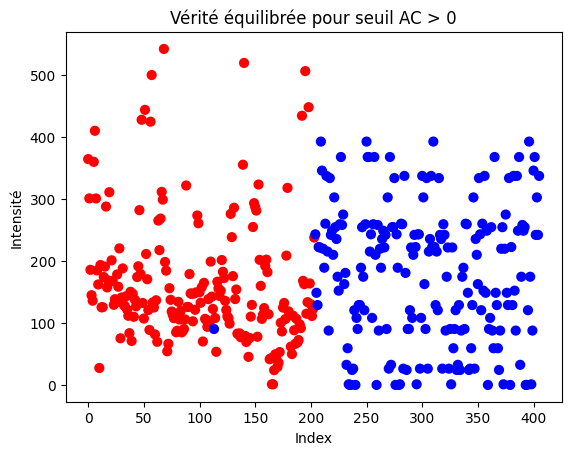

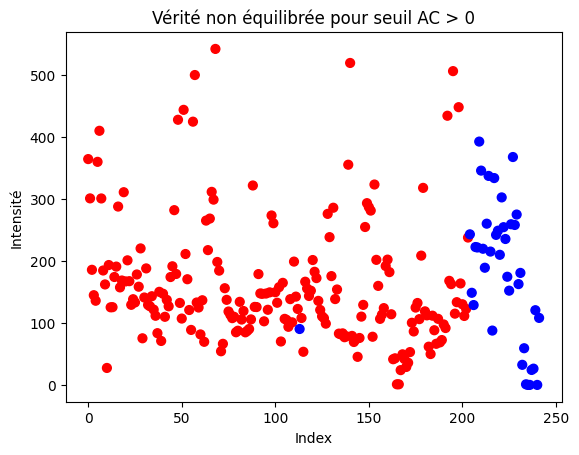

[('mouvement', 203), ('non mouvement', 203)]


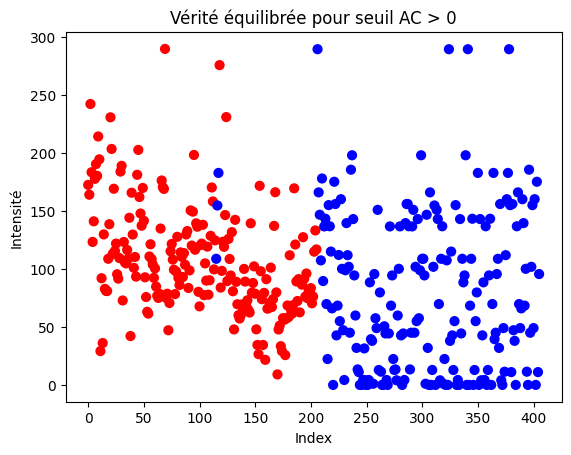

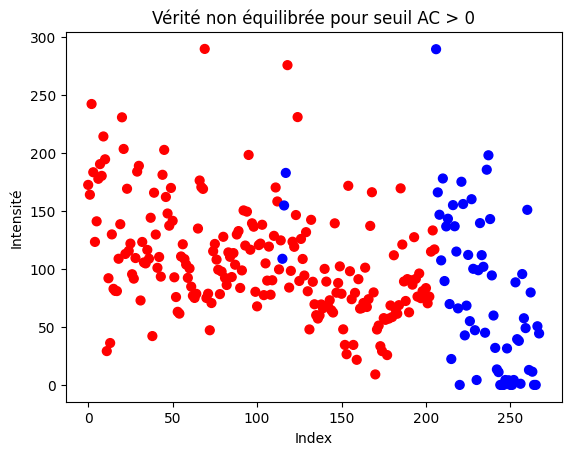

In [17]:
lst_X_members = [X_dom, X_non_dom]
lst_Y_members = [Y_dom, Y_non_dom]
balanced_X_members = []
balanced_Y_members = []

for idx_member in range(2):
    # ********************************** Préparation des données (équilibre, suppression des None,) *****************************************************************
    # Convertir en array pour faciliter le filtrage
    X_array = np.array(lst_X_members[idx_member])
    Y_array = np.array(lst_Y_members[idx_member])
    # Créer un masque pour garder uniquement les étiquettes valides (différent de None)
    mask_None = Y_array != None
    # Appliquer le masque
    X_clean = X_array[mask_None]
    Y_clean = Y_array[mask_None]

    # Aplatir les données (mettre au bon format pour les modèles)
    X_flat = np.vstack(X_clean)  # (n_total_samples, n_features)
    Y_flat = np.hstack(Y_clean)  # (n_total_samples,)

    # Equilibrer en sur échantillonant la classe minoritaire. Test de : RandomOverSampler (créer des points à coté des points existants), SMOTE (créer de nouveaux points entre les points existants), ADASYN (créer de nouveaux points entre les points existants mal classifiés).

    # RandomOverSampling
    ros = RandomOverSampler(random_state=0)
    X_balanced, Y_balanced = ros.fit_resample(X_flat, Y_flat)

    # SMOTE
    #X_balanced, Y_balanced = SMOTE().fit_resample(X_flat, Y_flat)

    # ADASYN
    #X_balanced, Y_balanced = ADASYN().fit_resample(X_flat, Y_flat)

    # Enregistrer les valeurs
    balanced_X_members.append(X_balanced) # balanced_X_members.append(X_flat) #
    balanced_Y_members.append(Y_balanced) # balanced_Y_members.append(Y_flat) # 
   

    # Vérifier que les classes sont bien équilibrées
    print(sorted(Counter(Y_balanced).items()))

    # ------------------------------------------- Vérité --------------------------------------
    # Crée un mapping de couleur pour chaque label
    label_to_color = {'mouvement': 'red', 'non mouvement': 'blue'}
    colors = [label_to_color[y] for y in Y_balanced]
    # Affichage : index en abscisse, intensité en ordonnée
    plt.scatter(range(len(X_balanced)), X_balanced[:, 0], c=colors, s=40)
    plt.title("Vérité équilibrée pour seuil AC > 0")
    plt.xlabel("Index")
    plt.ylabel("Intensité")
    plt.show()

    # Crée un mapping de couleur pour chaque label
    label_to_color = {'mouvement': 'red', 'non mouvement': 'blue'}
    colors = [label_to_color[y] for y in Y_flat]
    # Affichage : index en abscisse, intensité en ordonnée
    plt.scatter(range(len(X_flat)), X_flat[:, 0], c=colors, s=40)
    plt.title("Vérité non équilibrée pour seuil AC > 0")
    plt.xlabel("Index")
    plt.ylabel("Intensité")
    plt.show()


Analyse métriques

0


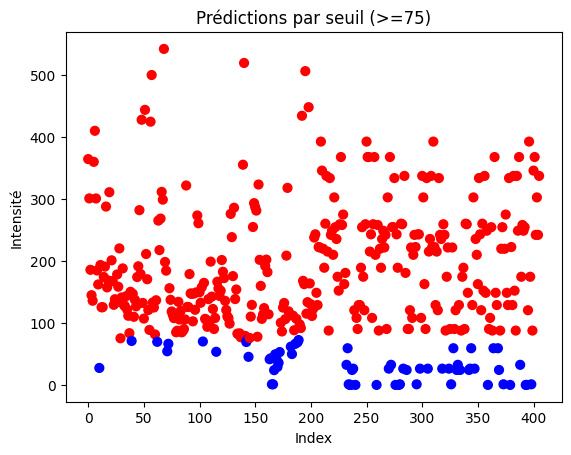

F1 score :  0.29850746268656714
F1 score :  0.6544117647058824
Accuracy pour seuil > 75 : 0.54


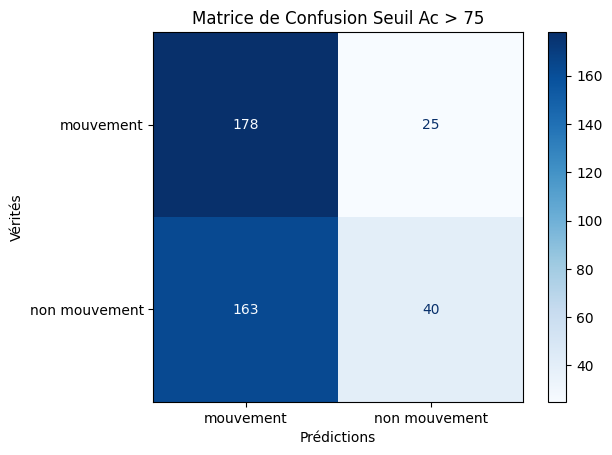

0


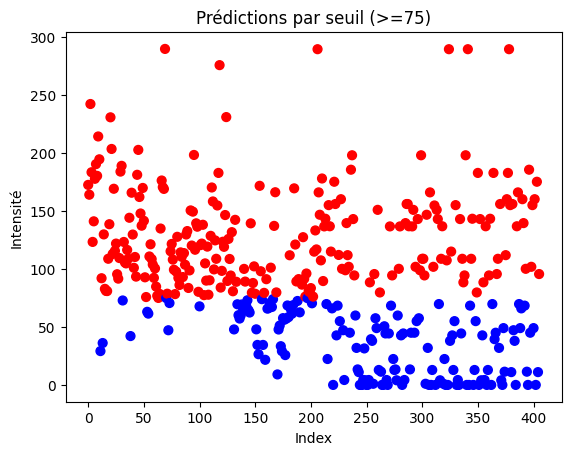

F1 score :  0.5944444444444444
F1 score :  0.6769911504424779
Accuracy pour seuil > 75 : 0.64


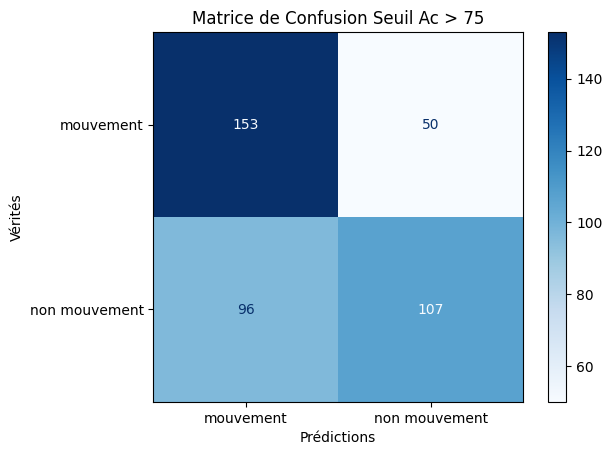

In [18]:

for idx_member in range(2):
    #********************************* Seuil AC > 75 **********************************************************************************
    #On a X_dom et Y_dom : construire un Y_pred_2 et le comparer à Y_dom
    Y_pred_75 = []
    print(len(Y_pred_75))
    for idx_data in range(0,len(balanced_X_members[idx_member])):
        #seuil = X_flat[idx_data] + X_flat[idx_data+1] # //////////////////////////
        seuil = balanced_X_members[idx_member][idx_data]
        if seuil >= 75 :
            Y_pred_75.append("mouvement")
        elif seuil < 75 :
            Y_pred_75.append("non mouvement")
        else:
            print(None)
            Y_pred_75.append(None)
    
    # Crée un mapping de couleur pour chaque label
    label_to_color = {'mouvement': 'red', 'non mouvement': 'blue'}
    colors = [label_to_color[y] for y in Y_pred_75]
    # Affichage : index en abscisse, intensité en ordonnée
    plt.scatter(range(len(balanced_X_members[idx_member])), balanced_X_members[idx_member], c=colors, s=40)
    plt.title("Prédictions par seuil (>=75)")
    plt.xlabel("Index")
    plt.ylabel("Intensité")
    plt.show()

    # Evaluate the model
    # F1 score
    f1score_mouvement = f1_score(balanced_Y_members[idx_member], Y_pred_75, labels = ["non mouvement","mouvement"], pos_label = "mouvement")
    f1score_non_mouvement = f1_score(balanced_Y_members[idx_member], Y_pred_75, labels = ["non mouvement","mouvement"], pos_label = "non mouvement")
    print("F1 score : ", f1score_non_mouvement)
    print("F1 score : ", f1score_mouvement)

    # Accuracy
    accuracy = accuracy_score(balanced_Y_members[idx_member], Y_pred_75)
    print(f"Accuracy pour seuil > 75 : {accuracy:.2f}")
    cm_75 = confusion_matrix(balanced_Y_members[idx_member], Y_pred_75)

    # Afficher la matrice de confusion
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_75, display_labels= ["mouvement", "non mouvement"])
    disp.plot(cmap="Blues")
    disp.ax_.set_title("Matrice de Confusion Seuil Ac > 75")
    disp.ax_.set_xlabel("Prédictions")
    disp.ax_.set_ylabel("Vérités")
    #disp.figure_.show()
    plt.show()